In [2]:
#imported the file from my drive
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
online_retail=pd.read_excel('/content/drive/MyDrive/My Report/Online Retail.xlsx')
online_retail.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [3]:
#saved the raw file so i can always access it whenever i desire and to prevent too much stress when when i lose my data
Online_1=online_retail.copy()

In [4]:
Online_1.shape

(541909, 8)

In [5]:
#checking the info of the file;our data types are only object,integers,datetime and float
Online_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
#checking for further info such as total rows, mean,min etc.
Online_1.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
#checking for duplicates
Online_1.duplicated().sum().any()

True

In [8]:
#dropping duplicates
Online_1.drop_duplicates(inplace=True)

In [9]:
#after dropping we still check if there are any further duplicates and the result is false
Online_1.duplicated().sum().any()

False

In [10]:
#checking for missing values
Online_1.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [11]:
#dropping missing values
Online_1.dropna(inplace=True)

In [12]:
#after dropping missing values we check if our result is exactly as desired
Online_1.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [13]:
#printing the data to see our result on the dataframe
Online_1.head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [14]:
#converting negative values to positive because some quantities were negative which is unlikely
Online_1["Quantity"]=Online_1["Quantity"].abs()
Online_1["UnitPrice"]=Online_1["UnitPrice"].abs()

In [15]:
#checking the dataframe
Online_1.head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [16]:
Online_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.6+ MB


In [17]:
#grouping countries by quantity to know the country that has highest number of products for the two years combine
Online_2=Online_1.groupby(['Country'])['Quantity'].sum()
Online_2

Country
Australia                 84755
Austria                    4935
Bahrain                     260
Belgium                   23322
Brazil                      356
Canada                     2763
Channel Islands            9497
Cyprus                     6384
Czech Republic              750
Denmark                    8282
EIRE                     144579
European Community          501
Finland                   10742
France                   113052
Germany                  120971
Greece                     1558
Iceland                    2458
Israel                     4099
Italy                      8225
Japan                     26814
Lebanon                     386
Lithuania                   652
Malta                       996
Netherlands              201746
Norway                    19429
Poland                     3715
Portugal                  16173
RSA                         352
Saudi Arabia                 85
Singapore                  5248
Spain                     29071


In [18]:
Online_3=Online_2.sort_values(ascending=False)
Online_3

Country
United Kingdom          4513204
Netherlands              201746
EIRE                     144579
Germany                  120971
France                   113052
Australia                 84755
Sweden                    36524
Switzerland               30388
Spain                     29071
Japan                     26814
Belgium                   23322
Norway                    19429
Portugal                  16173
Finland                   10742
Channel Islands            9497
Denmark                    8282
Italy                      8225
Cyprus                     6384
Singapore                  5248
Austria                    4935
Israel                     4099
USA                        3882
Poland                     3715
Canada                     2763
Iceland                    2458
Unspecified                1785
Greece                     1558
Malta                       996
United Arab Emirates        982
Czech Republic              750
Lithuania                   652


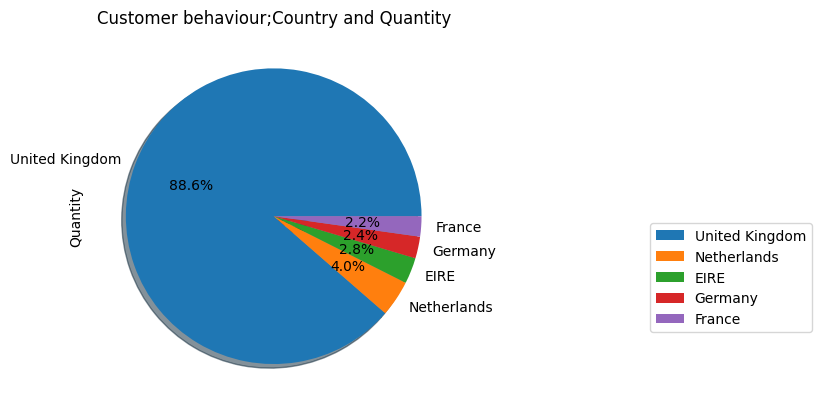

In [19]:
#plotting a pie chart for Online_3 for fisrt 5 countries to show the customer behaviour
Online_3.head(5).plot(kind='pie',autopct='%1.1f%%',shadow=True)
plt.legend(loc='upper left',bbox_to_anchor=(1.5,0.5))
plt.title('Customer behaviour;Country and Quantity')
plt.show()

In [20]:
#checking for total number of countries that patronised the company
Online_1['Country'].nunique()

37

In [21]:
#printing the countries by name
Online_1['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

In [22]:
#checking for the information of the country; 'Unspecified'
Online_1[Online_1['Country']=='Unspecified']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
152712,549687,20685,DOORMAT RED RETROSPOT,2,2011-04-11 13:29:00,7.95,12363.0,Unspecified
152713,549687,22691,DOORMAT WELCOME SUNRISE,2,2011-04-11 13:29:00,7.95,12363.0,Unspecified
152714,549687,48116,DOORMAT MULTICOLOUR STRIPE,2,2011-04-11 13:29:00,7.95,12363.0,Unspecified
152715,549687,21213,PACK OF 72 SKULL CAKE CASES,24,2011-04-11 13:29:00,0.55,12363.0,Unspecified
152716,549687,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,2011-04-11 13:29:00,0.55,12363.0,Unspecified
...,...,...,...,...,...,...,...,...
308810,564051,23007,SPACEBOY BABY GIFT SET,1,2011-08-22 13:32:00,16.95,14265.0,Unspecified
308811,564051,21833,CAMOUFLAGE LED TORCH,12,2011-08-22 13:32:00,1.69,14265.0,Unspecified
308812,564051,23081,GREEN METAL BOX ARMY SUPPLIES,2,2011-08-22 13:32:00,8.25,14265.0,Unspecified
308813,564051,23046,PAPER LANTERN 9 POINT DELUXE STAR,2,2011-08-22 13:32:00,6.65,14265.0,Unspecified


In [23]:
#There are missing data in this column that are entered as 'Unspecified'
#more efforts should be put into getting customer details for customer tracking,communication,encouraging good customer transaction and fostering better customer retension
#this can be done by making all fields mandatory

In [24]:
#number of years the transaction spans through 2years
Online_1['InvoiceDate'].dt.year.nunique()


2

In [25]:
#Checking for CustomerID by month
Online_1.groupby(Online_1['InvoiceDate'].dt.month)['CustomerID'].nunique()


InvoiceDate
1      783
2      798
3     1020
4      899
5     1079
6     1051
7      993
8      980
9     1302
10    1425
11    1711
12    1374
Name: CustomerID, dtype: int64

In [26]:
#Checking for customerID by year
Online_1.groupby(Online_1['InvoiceDate'].dt.year)['CustomerID'].nunique()

InvoiceDate
2010     948
2011    4244
Name: CustomerID, dtype: int64

In [27]:
#copying the work to a variable we can call at will so as not to lose our work done so far
data=Online_1.copy()
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [28]:
#adding a column "InvoiceDate_Month" to the new variable we created maintaining our original dataframe intact
data['InvoiceDate_Month']=data['InvoiceDate'].dt.month
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDate_Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12


In [29]:
#printing InvoiceDate_Month in month name such as jan,feb,march
data['InvoiceDate_Month']=data['InvoiceDate_Month'].map({1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'})
data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDate_Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December


In [30]:
#sorting our new dataframe to arrange in order of date and time
data.sort_values(by=['InvoiceDate'],inplace=True)
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDate_Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
...,...,...,...,...,...,...,...,...,...
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680.0,France,December
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680.0,France,December
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,December
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France,December


In [31]:
#checking out our dataframe to see the sorting implemented
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDate_Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
...,...,...,...,...,...,...,...,...,...
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680.0,France,December
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680.0,France,December
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,December
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France,December


In [32]:
#printing 2010 dataframe from the general dataframe
New_data=data[data['InvoiceDate'].dt.year==2010]
New_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDate_Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December
...,...,...,...,...,...,...,...,...,...
42387,539988,22556,PLASTERS IN TIN CIRCUS PARADE,1,2010-12-23 16:06:00,1.65,18116.0,United Kingdom,December
42392,539988,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5,2010-12-23 16:06:00,2.95,18116.0,United Kingdom,December
42393,539988,21733,RED HANGING HEART T-LIGHT HOLDER,3,2010-12-23 16:06:00,2.95,18116.0,United Kingdom,December
42394,539988,22804,CANDLEHOLDER PINK HANGING HEART,5,2010-12-23 16:06:00,2.95,18116.0,United Kingdom,December


In [33]:
#the sum total of customerIDs for the year 2010
data[data['InvoiceDate'].dt.year==2010]['CustomerID'].nunique()

948

In [34]:
#grouping quantity and InvoiceDate_Month for year 2010 so as to know the month with the highest order
data[data['InvoiceDate'].dt.year==2010].groupby(['InvoiceDate_Month'])['Quantity'].sum()
#the year 2010 only saw a purchase in the month of December

InvoiceDate_Month
December    326949
Name: Quantity, dtype: int64

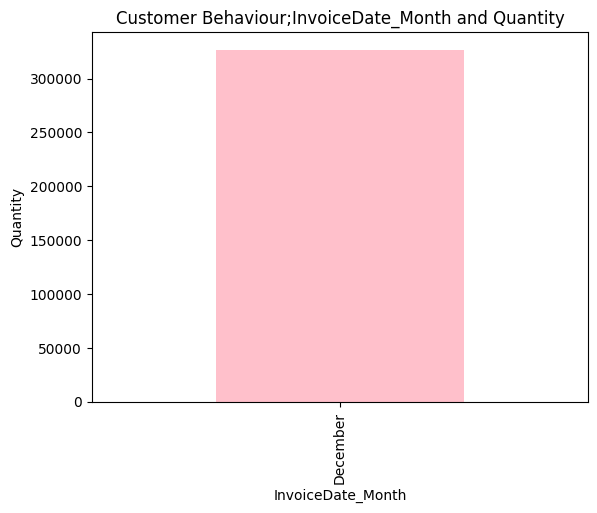

In [118]:
#using a bar chart to represent the data
data[data['InvoiceDate'].dt.year==2010].groupby(['InvoiceDate_Month'])['Quantity'].sum().plot(kind='bar',color='pink')
plt.title('Customer Behaviour;InvoiceDate_Month and Quantity')
plt.xlabel('InvoiceDate_Month')
plt.ylabel('Quantity')
plt.show()

# data[data['InvoiceDate'].dt.year==2010].groupby(['InvoiceDate_Month'])['Quantity'].sum().plot(kind='pie',autopct='%1.1f%%')
# plt.legend(loc='upper left',bbox_to_anchor=(1.5,0.5))
# plt.title('Customer Behaviour;InvoiceDate_Month and Quantity')
# plt.show()

In [36]:
#grouping quantities and country for year 2010 so as to know the countries that orders the most quantity
Data_1=data[data['InvoiceDate'].dt.year==2010].groupby(['Country'])['Quantity'].sum()
Data_1

Country
Australia             470
Austria                99
Belgium              1755
Channel Islands        80
Cyprus                916
Denmark               454
EIRE                 5648
Finland              1254
France               5000
Germany              7021
Iceland               319
Israel                 56
Italy                 297
Japan                4093
Lithuania             652
Netherlands          6811
Norway               3582
Poland                140
Portugal             1023
Spain                 867
Sweden               4194
Switzerland           714
United Kingdom     281504
Name: Quantity, dtype: int64

In [37]:
Data_2=Data_1.sort_values(ascending=False)
Data_2

Country
United Kingdom     281504
Germany              7021
Netherlands          6811
EIRE                 5648
France               5000
Sweden               4194
Japan                4093
Norway               3582
Belgium              1755
Finland              1254
Portugal             1023
Cyprus                916
Spain                 867
Switzerland           714
Lithuania             652
Australia             470
Denmark               454
Iceland               319
Italy                 297
Poland                140
Austria                99
Channel Islands        80
Israel                 56
Name: Quantity, dtype: int64

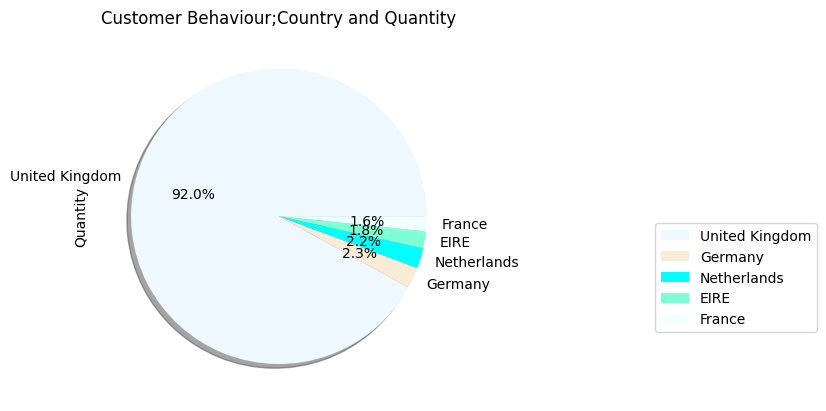

In [115]:
import matplotlib.colors as mcolors
#ploting a pie chart for Data_2 for head(5)
colors = list(mcolors.CSS4_COLORS.values())
Data_2.head(5).plot(kind='pie',autopct='%1.1f%%',colors=colors,shadow=True)
plt.legend(loc='upper left',bbox_to_anchor=(1.5,0.5))
plt.title('Customer Behaviour;Country and Quantity')
plt.show()


In [39]:
#to know the total count of countries that ordered from the company in that year,2010
data[data['InvoiceDate'].dt.year==2010].groupby(['Country'])['Quantity'].sum().nunique()

23

In [40]:
#grouping Description and country for year 2010, to know the kind of product that a particular country orders most
Retail=data[data['InvoiceDate'].dt.year==2010].groupby(['Description'])['Quantity'].sum()
Retail

Description
 4 PURPLE FLOCK DINNER CANDLES        14
 OVAL WALL MIRROR DIAMANTE             9
 SET 2 TEA TOWELS I LOVE LONDON      254
10 COLOUR SPACEBOY PEN               558
12 COLOURED PARTY BALLOONS            48
                                    ... 
ZINC HEART LATTICE CHARGER SMALL       4
ZINC HEART LATTICE T-LIGHT HOLDER     24
ZINC METAL HEART DECORATION          505
ZINC TOP  2 DOOR WOODEN SHELF          6
ZINC WILLIE WINKIE  CANDLE STICK     174
Name: Quantity, Length: 2429, dtype: int64

In [41]:
Retail_1=Retail.sort_values(ascending=False)
Retail_1

Description
ROTATING SILVER ANGELS T-LIGHT HLDR    11175
WORLD WAR 2 GLIDERS ASSTD DESIGNS       5139
WHITE HANGING HEART T-LIGHT HOLDER      4139
PACK OF 72 RETROSPOT CAKE CASES         3602
HAND WARMER BABUSHKA DESIGN             3461
                                       ...  
EAU DE NILE JEWELLED PHOTOFRAME            1
SILVER/MOP ORBIT NECKLACE                  1
SILVER TEDDY BEAR                          1
SILVER T-LIGHT SETTING                     1
LETTER "V" BLING KEY RING                  1
Name: Quantity, Length: 2429, dtype: int64

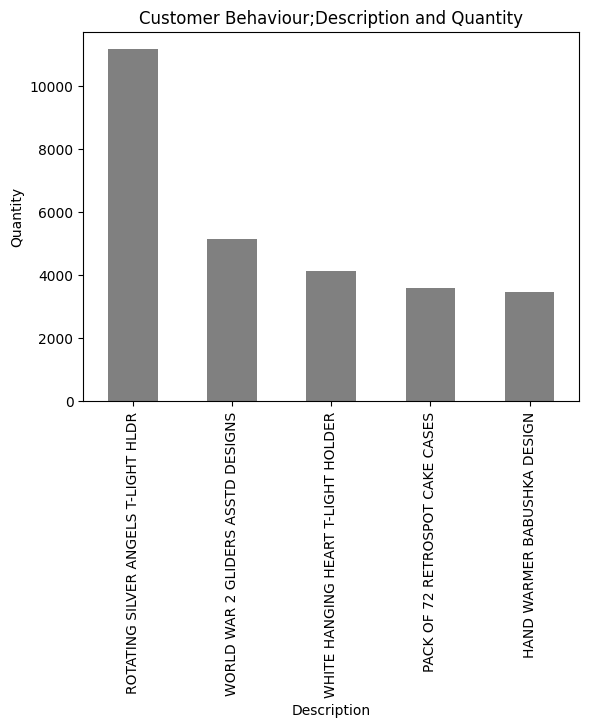

In [108]:
#Using bar chart for Pan_1 for first 5
Retail_1.head(5).plot(kind='bar',color='grey')
plt.title('Customer Behaviour;Description and Quantity')
plt.xlabel('Description')
plt.ylabel('Quantity')
plt.show()

In [43]:
#showing the the number of rows and columns in the new dataframe,2010
New_data.shape

(26354, 9)

In [44]:
#grouping Description, country and quantity for year 2010, showing the particular kind of product a country buys most
New_data_1=New_data[New_data['InvoiceDate'].dt.year==2010].groupby(['Description','Country'])['Quantity'].sum()
New_data_1

#data[data['InvoiceDate'].dt.year==2010].groupby(['Description'])['Country'].sum()

Description                        Country       
 4 PURPLE FLOCK DINNER CANDLES     United Kingdom     14
 OVAL WALL MIRROR DIAMANTE         United Kingdom      9
 SET 2 TEA TOWELS I LOVE LONDON    France             24
                                   United Kingdom    230
10 COLOUR SPACEBOY PEN             EIRE               24
                                                    ... 
ZINC HEART LATTICE T-LIGHT HOLDER  United Kingdom      4
ZINC METAL HEART DECORATION        France             12
                                   United Kingdom    493
ZINC TOP  2 DOOR WOODEN SHELF      United Kingdom      6
ZINC WILLIE WINKIE  CANDLE STICK   United Kingdom    174
Name: Quantity, Length: 4135, dtype: int64

In [45]:
New_data_2=New_data_1.sort_values(ascending=False)
New_data_2


Description                          Country       
ROTATING SILVER ANGELS T-LIGHT HLDR  United Kingdom    11133
WORLD WAR 2 GLIDERS ASSTD DESIGNS    United Kingdom     4515
WHITE HANGING HEART T-LIGHT HOLDER   United Kingdom     3996
HAND WARMER BABUSHKA DESIGN          United Kingdom     3293
PACK OF 72 RETROSPOT CAKE CASES      United Kingdom     2762
                                                       ...  
CUBIC MUG PINK POLKADOT              United Kingdom        1
CRYSTAL HOOP EARRING FLORAL LEAF     United Kingdom        1
CRYSTAL FROG PHONE CHARM             United Kingdom        1
SMALL POP BOX,FUNKY MONKEY           United Kingdom        1
POPPY'S PLAYHOUSE BATHROOM           Cyprus                1
Name: Quantity, Length: 4135, dtype: int64

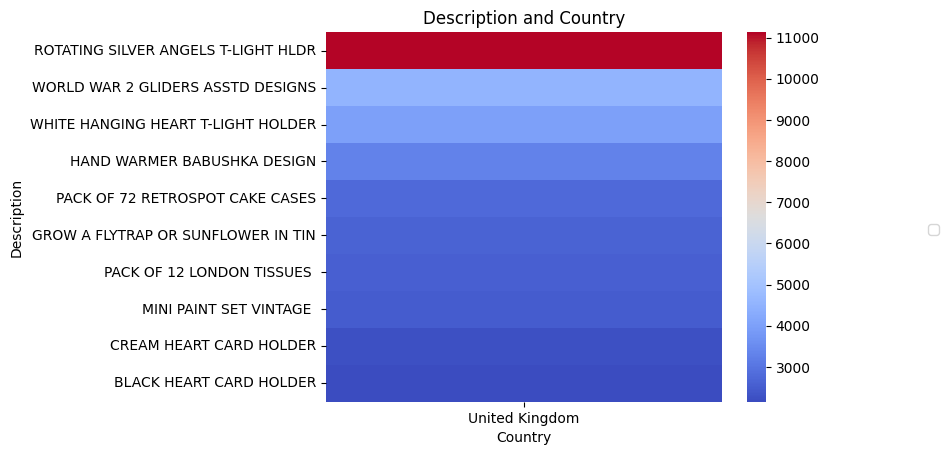

In [46]:
import seaborn as sns
#representing this data using heatmap first 10 for better visualization
sns.heatmap(New_data_2.head(10).unstack(),cmap='coolwarm')
legend_labels = New_data_2.head(10).unstack().columns
plt.legend(legend_labels,loc='upper left',bbox_to_anchor=(1.5,0.5))
plt.title('Description and Country')
plt.show()
#where the fig shows an increasing order of a product description from below 4000 to above 10000 as indicated by the red bar showing a high demand and from  country

In [47]:
#from the general dataframe we called another sub-dataframe for the year 2011
#from data print data for 2011
New_frame=data[data['InvoiceDate'].dt.year==2011]
New_frame

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDate_Month
42491,539993,22896,PEG BAG APPLES DESIGN,6,2011-01-04 10:00:00,2.55,13313.0,United Kingdom,January
42497,539993,22862,LOVE HEART NAPKIN BOX,4,2011-01-04 10:00:00,4.25,13313.0,United Kingdom,January
42496,539993,22458,CAST IRON HOOK GARDEN FORK,8,2011-01-04 10:00:00,2.55,13313.0,United Kingdom,January
42495,539993,22808,SET OF 6 T-LIGHTS EASTER CHICKS,12,2011-01-04 10:00:00,2.95,13313.0,United Kingdom,January
42494,539993,85123A,WHITE HANGING HEART T-LIGHT HOLDER,12,2011-01-04 10:00:00,2.95,13313.0,United Kingdom,January
...,...,...,...,...,...,...,...,...,...
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680.0,France,December
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680.0,France,December
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,December
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France,December


In [48]:
New_frame.shape

(375250, 9)

In [49]:
#CustomerID for year 2011
New_frame[New_frame['InvoiceDate'].dt.year==2011]['CustomerID'].unique()


array([13313., 18097., 16656., ..., 13298., 14569., 12713.])

In [50]:
#to know the total count of countries that ordered from the company in that year,2011
New_frame[New_frame['InvoiceDate'].dt.year==2011].groupby(['Country'])['Quantity'].sum().nunique()

36

In [51]:
#printing the countries that in 2011
Country_Quantity=New_frame[New_frame['InvoiceDate'].dt.year==2011].groupby(['Country'])['Quantity'].sum()
Country_Quantity


Country
Australia                 84285
Austria                    4836
Bahrain                     260
Belgium                   21567
Brazil                      356
Canada                     2763
Channel Islands            9417
Cyprus                     5468
Czech Republic              750
Denmark                    7828
EIRE                     138931
European Community          501
Finland                    9488
France                   108052
Germany                  113950
Greece                     1558
Iceland                    2139
Israel                     4043
Italy                      7928
Japan                     22721
Lebanon                     386
Malta                       996
Netherlands              194935
Norway                    15847
Poland                     3575
Portugal                  15150
RSA                         352
Saudi Arabia                 85
Singapore                  5248
Spain                     28204
Sweden                    32330


In [52]:
Country_Quantity_1=Country_Quantity.sort_values(ascending=False)
Country_Quantity_1

Country
United Kingdom          4231700
Netherlands              194935
EIRE                     138931
Germany                  113950
France                   108052
Australia                 84285
Sweden                    32330
Switzerland               29674
Spain                     28204
Japan                     22721
Belgium                   21567
Norway                    15847
Portugal                  15150
Finland                    9488
Channel Islands            9417
Italy                      7928
Denmark                    7828
Cyprus                     5468
Singapore                  5248
Austria                    4836
Israel                     4043
USA                        3882
Poland                     3575
Canada                     2763
Iceland                    2139
Unspecified                1785
Greece                     1558
Malta                       996
United Arab Emirates        982
Czech Republic              750
European Community          501


In [53]:
#determining the number of countries in Country_Quantity_1
Country_Quantity_1.shape

(36,)

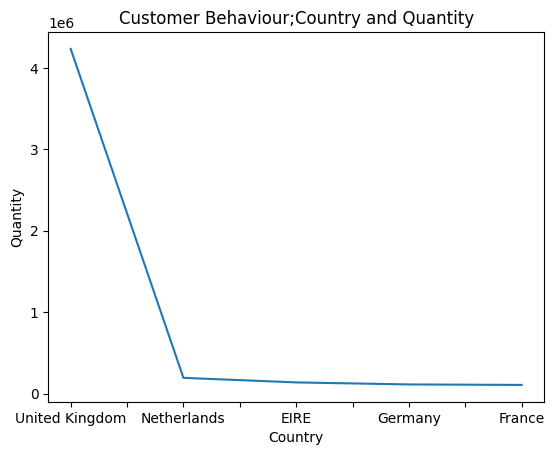

In [54]:
#using a line  trend to show the relationship
Country_Quantity_1.head(5).plot(kind='line')
plt.title('Customer Behaviour;Country and Quantity')
plt.xlabel('Country')
plt.ylabel('Quantity')
plt.show()

In [55]:
#CustomerID for year 2011
New_frame[New_frame['InvoiceDate'].dt.year==2011]['CustomerID'].nunique()

4244

In [56]:
#grouping quantity and InvoiceDate_Month for year 2011; to determine the month the highest quantity was ordered
Month_Quantity=New_frame[New_frame['InvoiceDate'].dt.year==2011].groupby(['InvoiceDate_Month'])['Quantity'].sum()
Month_Quantity
# data.groupby(['InvoiceDate_Month'])['Quantity'].sum()

InvoiceDate_Month
April        305008
August       410515
December     370342
February     267843
January      428289
July         373385
June         369789
March        352151
May          378781
November     690707
October      614204
September    550958
Name: Quantity, dtype: int64

In [57]:
#sorting the values
Month_Quantity_1=Month_Quantity.sort_values(ascending=False)
Month_Quantity_1

InvoiceDate_Month
November     690707
October      614204
September    550958
January      428289
August       410515
May          378781
July         373385
December     370342
June         369789
March        352151
April        305008
February     267843
Name: Quantity, dtype: int64

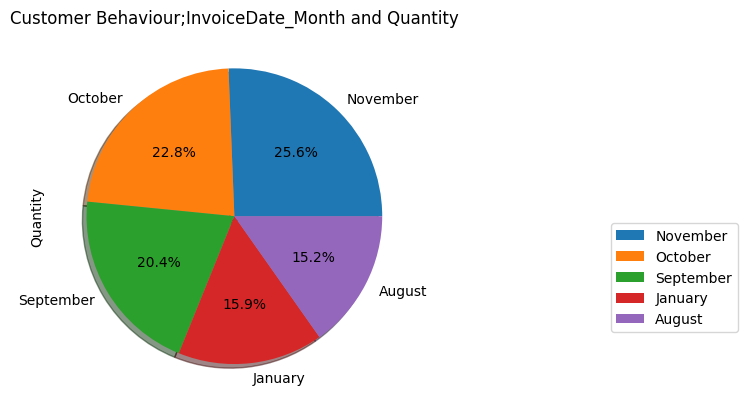

In [58]:
#using a pie chart to represent Month_Quantity_1
Month_Quantity_1.head(5).plot(kind='pie',autopct='%1.1f%%',shadow=True)
plt.legend(loc='upper left',bbox_to_anchor=(1.5,0.5))
plt.title('Customer Behaviour;InvoiceDate_Month and Quantity')
plt.show()

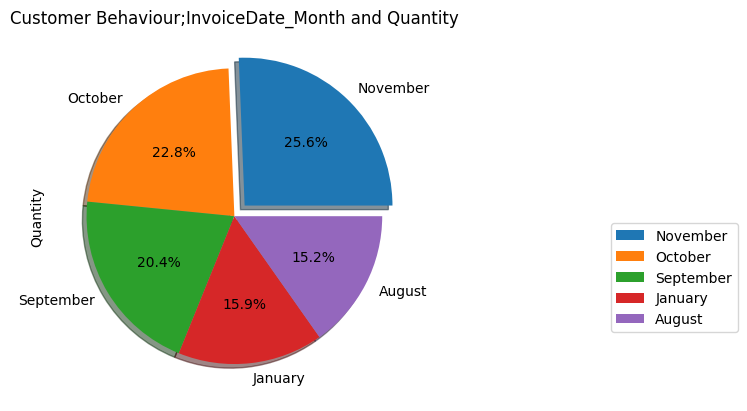

In [59]:
#isolatinjg november for proper understanding
explode=[0.1,0,0,0,0]
Month_Quantity_1.head(5).plot(kind='pie',autopct='%1.1f%%',explode=explode,shadow=True)
plt.legend(loc='upper left',bbox_to_anchor=(1.5,0.5))
plt.title('Customer Behaviour;InvoiceDate_Month and Quantity')
plt.show()

In [60]:
#grouping by description and quantity for New_frame
Description_Quantity=New_frame[New_frame['InvoiceDate'].dt.year==2011].groupby(['Description'])['Quantity'].sum()
Description_Quantity

Description
 4 PURPLE FLOCK DINNER CANDLES       124
 50'S CHRISTMAS GIFT BAG LARGE      1887
 DOLLY GIRL BEAKER                  2401
 I LOVE LONDON MINI BACKPACK         359
 I LOVE LONDON MINI RUCKSACK           1
                                    ... 
ZINC T-LIGHT HOLDER STARS SMALL     4938
ZINC TOP  2 DOOR WOODEN SHELF          9
ZINC WILLIE WINKIE  CANDLE STICK    2444
ZINC WIRE KITCHEN ORGANISER           25
ZINC WIRE SWEETHEART LETTER TRAY      80
Name: Quantity, Length: 3800, dtype: int64

In [61]:
#sorting Description_Quantity
Description_Quantity_1=Description_Quantity.sort_values(ascending=False)
Description_Quantity_1

Description
PAPER CRAFT , LITTLE BIRDIE           161990
MEDIUM CERAMIC TOP STORAGE JAR        152410
WORLD WAR 2 GLIDERS ASSTD DESIGNS      50380
JUMBO BAG RED RETROSPOT                45111
WHITE HANGING HEART T-LIGHT HOLDER     35145
                                       ...  
FAIRY CAKE NOTEBOOK A5 SIZE                1
CAPIZ CHANDELIER                           1
MUMMY MOUSE RED GINGHAM RIBBON             1
MURANO STYLE GLASS BRACELET BLACK          1
OLD DOC RUSSEL METAL SIGN                  1
Name: Quantity, Length: 3800, dtype: int64

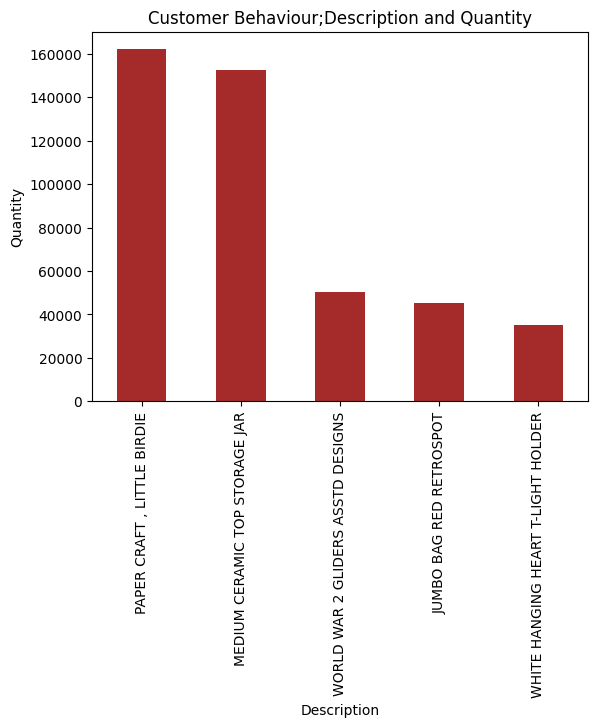

In [124]:
#using a histogram to show Description_Quantit_1 for first 5
Description_Quantity_1.head(5).plot(kind='bar',color='brown')
plt.title('Customer Behaviour;Description and Quantity')
plt.xlabel('Description')
plt.ylabel('Quantity')
plt.show()


In [63]:
#grouping description, country and quantity from New_frame
Description_Quantity_2=New_frame[New_frame['InvoiceDate'].dt.year==2011].groupby(['Description','Country'])['Quantity'].sum()
Description_Quantity_2

Description                       Country       
 4 PURPLE FLOCK DINNER CANDLES    EIRE                 6
                                  United Kingdom     118
 50'S CHRISTMAS GIFT BAG LARGE    EIRE                48
                                  France              12
                                  Germany             60
                                                    ... 
ZINC WILLIE WINKIE  CANDLE STICK  United Kingdom    1844
ZINC WIRE KITCHEN ORGANISER       Portugal             1
                                  United Kingdom      24
ZINC WIRE SWEETHEART LETTER TRAY  EIRE                 8
                                  United Kingdom      72
Name: Quantity, Length: 18785, dtype: int64

In [64]:
Description_Quantity_3=Description_Quantity_2.sort_values(ascending=False)
Description_Quantity_3

Description                          Country       
PAPER CRAFT , LITTLE BIRDIE          United Kingdom    161990
MEDIUM CERAMIC TOP STORAGE JAR       United Kingdom    151386
WORLD WAR 2 GLIDERS ASSTD DESIGNS    United Kingdom     45771
JUMBO BAG RED RETROSPOT              United Kingdom     40987
WHITE HANGING HEART T-LIGHT HOLDER   United Kingdom     33185
                                                        ...  
ALARM CLOCK BAKELIKE RED             Unspecified            1
DOORMAT UNION JACK GUNS AND ROSES    Germany                1
ALARM CLOCK BAKELIKE RED             Netherlands            1
GREEN PENDANT TRIPLE SHELL NECKLACE  United Kingdom         1
PINK HEARTS LIGHT CHAIN              Unspecified            1
Name: Quantity, Length: 18785, dtype: int64

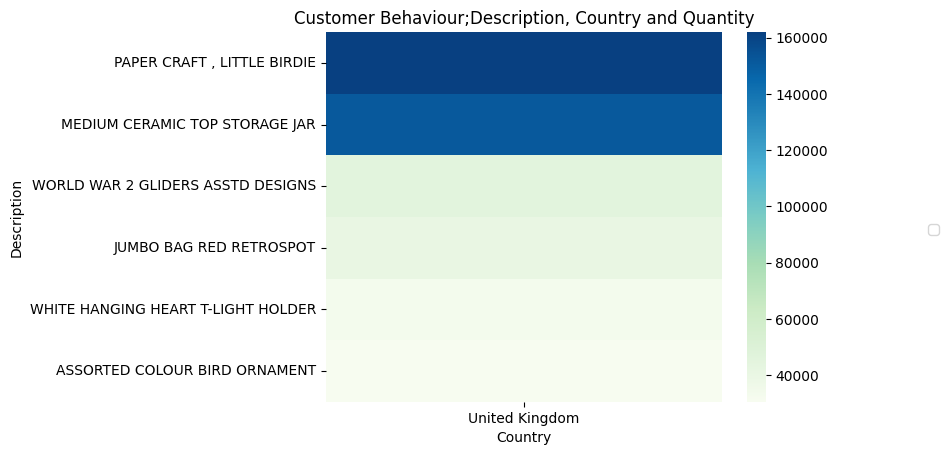

In [65]:
#using heat map to show the data
sns.heatmap(Description_Quantity_3.head(6).unstack(),cmap='GnBu')
legend_labels = Description_Quantity_3.head(6).unstack().columns
plt.legend(legend_labels,loc='upper left',bbox_to_anchor=(1.5,0.5))
plt.title('Customer Behaviour;Description, Country and Quantity')
plt.show()

In [66]:
#adding a sales column to data to the sub-dataframe
data['Sales']=data['Quantity']*data['UnitPrice']
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDate_Month,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,20.34


In [67]:
#grouping sales and InvoiceDate_Month for year 2010 to know the month with the highest sales
data[data['InvoiceDate'].dt.year==2010].groupby(['InvoiceDate_Month'])['Sales'].sum()

InvoiceDate_Month
December    588472.6
Name: Sales, dtype: float64

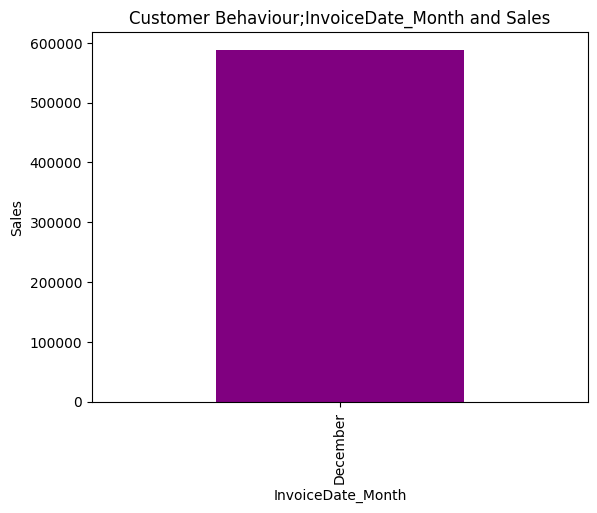

In [128]:
#using a bar chart to show the data for 2010
data[data['InvoiceDate'].dt.year==2010].groupby(['InvoiceDate_Month'])['Sales'].sum().plot(kind='bar',color='purple')
plt.title('Customer Behaviour;InvoiceDate_Month and Sales')
plt.xlabel('InvoiceDate_Month')
plt.ylabel('Sales')
plt.show()

In [69]:
#grouping country and sales so as to know the countries bringing in the higest sales.
#the highest sales comes from the country United Kingdom
Country_Sales=data[data['InvoiceDate'].dt.year==2010].groupby(['Country'])['Sales'].sum()
Country_Sales

Country
Australia             993.10
Austria               297.36
Belgium              1809.91
Channel Islands       363.53
Cyprus               1587.07
Denmark              1281.50
EIRE                 9802.19
Finland               892.80
France               9657.26
Germany             15884.04
Iceland               711.79
Israel                227.44
Italy                 828.50
Japan                7705.07
Lithuania            1661.06
Netherlands          8784.48
Norway               3787.12
Poland                248.16
Portugal             2499.82
Spain                1843.73
Sweden               5022.30
Switzerland          1304.92
United Kingdom     511279.45
Name: Sales, dtype: float64

In [70]:
Country_Sales_1=Country_Sales.sort_values(ascending=False)
Country_Sales_1


Country
United Kingdom     511279.45
Germany             15884.04
EIRE                 9802.19
France               9657.26
Netherlands          8784.48
Japan                7705.07
Sweden               5022.30
Norway               3787.12
Portugal             2499.82
Spain                1843.73
Belgium              1809.91
Lithuania            1661.06
Cyprus               1587.07
Switzerland          1304.92
Denmark              1281.50
Australia             993.10
Finland               892.80
Italy                 828.50
Iceland               711.79
Channel Islands       363.53
Austria               297.36
Poland                248.16
Israel                227.44
Name: Sales, dtype: float64

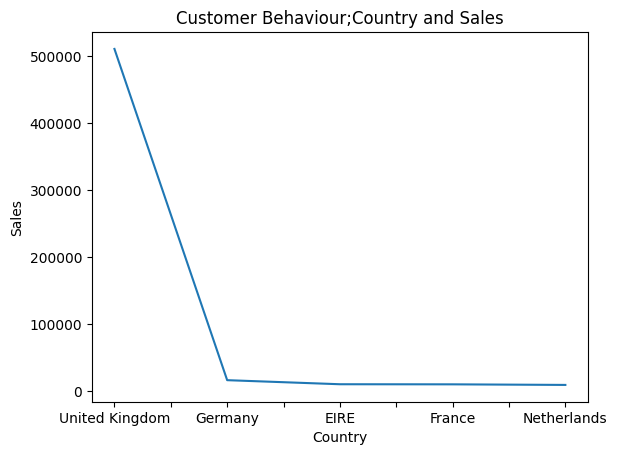

In [71]:
#plotting line chart for info_1 for first 5
Country_Sales_1.head(5).plot(kind='line')
plt.title('Customer Behaviour;Country and Sales')
plt.xlabel('Country')
plt.ylabel('Sales')
plt.show()

In [72]:
#grouping by description and sales
Description_Sales=data[data['InvoiceDate'].dt.year==2010].groupby(['Description'])['Sales'].sum()
Description_Sales

Description
 4 PURPLE FLOCK DINNER CANDLES        35.70
 OVAL WALL MIRROR DIAMANTE            89.55
 SET 2 TEA TOWELS I LOVE LONDON      749.30
10 COLOUR SPACEBOY PEN               474.30
12 COLOURED PARTY BALLOONS            31.20
                                      ...  
ZINC HEART LATTICE CHARGER SMALL      11.80
ZINC HEART LATTICE T-LIGHT HOLDER     30.00
ZINC METAL HEART DECORATION          631.25
ZINC TOP  2 DOOR WOODEN SHELF         93.70
ZINC WILLIE WINKIE  CANDLE STICK     147.90
Name: Sales, Length: 2429, dtype: float64

In [73]:
New_Sales=Description_Sales.sort_values(ascending=False)
New_Sales

Description
REGENCY CAKESTAND 3 TIER              18554.10
WHITE HANGING HEART T-LIGHT HOLDER    10958.45
VINTAGE UNION JACK MEMOBOARD           6938.49
WOOD BLACK BOARD ANT WHITE FINISH      6698.13
BLACK RECORD COVER FRAME               6248.82
                                        ...   
HEARTS WRAPPING TAPE                      0.65
SILICON STAR BULB  BLUE                   0.42
METAL BASE FOR CANDLES                    0.42
SILICON CUBE 25W, BLUE                    0.42
ASSORTED MONKEY SUCTION CUP HOOK          0.42
Name: Sales, Length: 2429, dtype: float64

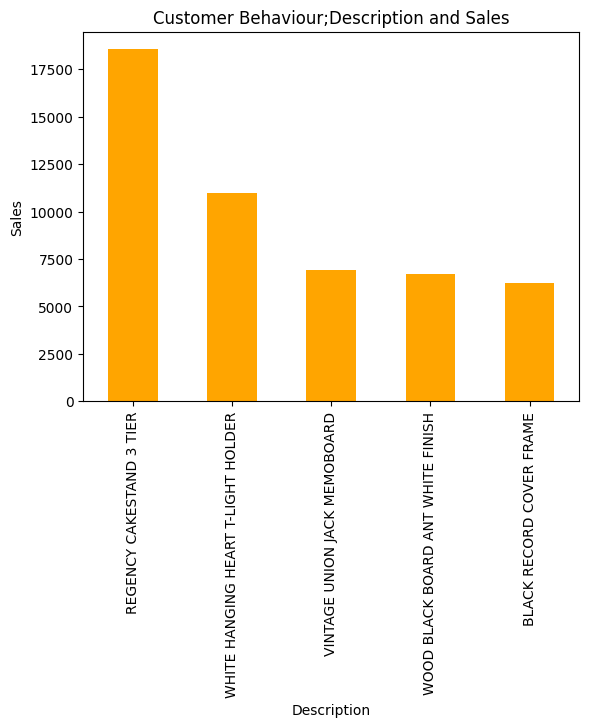

In [94]:
#using a bar chat
New_Sales.head(5).plot(kind='bar',color='orange')
plt.title('Customer Behaviour;Description and Sales')
plt.xlabel('Description')
plt.ylabel('Sales')
plt.show()

In [75]:
#grouping sales and InvoiceDate_Month for year 2011 to know the month with the highest sales
Month_Sales=data[data['InvoiceDate'].dt.year==2011].groupby(['InvoiceDate_Month'])['Sales'].sum()
Month_Sales

InvoiceDate_Month
April         511525.991
August        673023.990
December      692841.450
February      456635.770
January       662470.720
July          624813.481
June          713229.580
March         609587.310
May           707698.630
November     1185596.150
October      1097978.520
September     972024.172
Name: Sales, dtype: float64

In [76]:
#sorting values
Month_Sales_1=Month_Sales.sort_values(ascending=False)
Month_Sales_1

InvoiceDate_Month
November     1185596.150
October      1097978.520
September     972024.172
June          713229.580
May           707698.630
December      692841.450
August        673023.990
January       662470.720
July          624813.481
March         609587.310
April         511525.991
February      456635.770
Name: Sales, dtype: float64

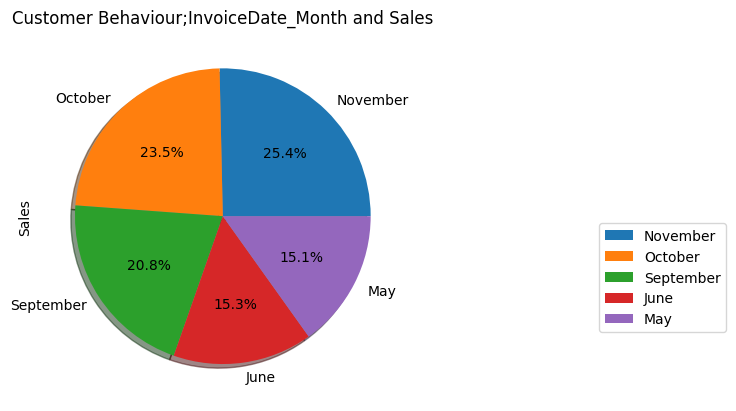

In [77]:
#using pie chart for top 5
Month_Sales_1.head(5).plot(kind='pie',autopct='%1.1f%%',shadow=True)
plt.legend(loc='upper left',bbox_to_anchor=(1.5,0.5))
plt.title('Customer Behaviour;InvoiceDate_Month and Sales')
plt.show()

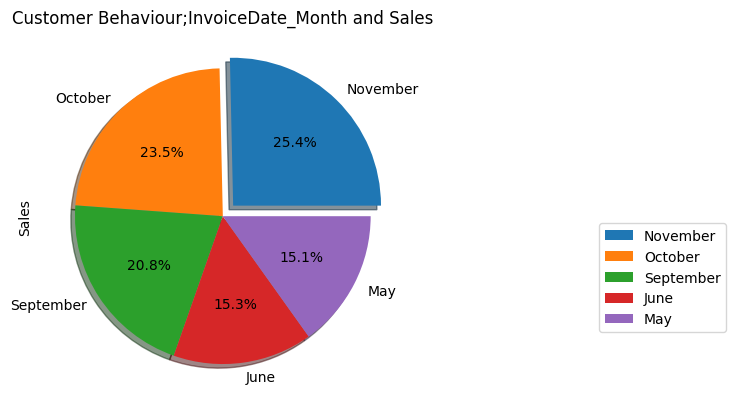

In [78]:
#projecting the month with the highest sales
Month_Sales_1.head(5).plot(kind='pie',autopct='%1.1f%%',explode=explode,shadow=True)
plt.legend(loc='upper left',bbox_to_anchor=(1.5,0.5))
plt.title('Customer Behaviour;InvoiceDate_Month and Sales')
plt.show()


In [79]:
#grouping by coun try and sales
New_Sales_1=data[data['InvoiceDate'].dt.year==2011].groupby(['Country'])['Sales'].sum()
New_Sales_1

Country
Australia                138904.750
Austria                    9945.680
Bahrain                     548.400
Belgium                   39671.810
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20441.160
Cyprus                    12559.870
Czech Republic              945.760
Denmark                   17861.040
EIRE                     270720.950
European Community         1308.750
Finland                   21872.620
France                   211585.310
Germany                  219963.290
Greece                     4810.520
Iceland                    3598.210
Israel                     7215.840
Italy                     17247.470
Japan                     31787.050
Lebanon                    1693.880
Malta                      2945.710
Netherlands              277446.660
Norway                    33380.300
Poland                     7208.000
Portugal                  35256.100
RSA                        1002.310
Saudi Arabia        

In [80]:
#sortring values
New_Sales_2=New_Sales_1.sort_values(ascending=False)
New_Sales_2


Country
United Kingdom          7311613.684
Netherlands              277446.660
EIRE                     270720.950
Germany                  219963.290
France                   211585.310
Australia                138904.750
Spain                     66517.360
Switzerland               55843.580
Belgium                   39671.810
Portugal                  35256.100
Sweden                    35127.950
Singapore                 33438.190
Norway                    33380.300
Japan                     31787.050
Finland                   21872.620
Channel Islands           20441.160
Denmark                   17861.040
Italy                     17247.470
Cyprus                    12559.870
Austria                    9945.680
Israel                     7215.840
Poland                     7208.000
USA                        5429.860
Greece                     4810.520
Canada                     3666.380
Iceland                    3598.210
Malta                      2945.710
Unspecified         

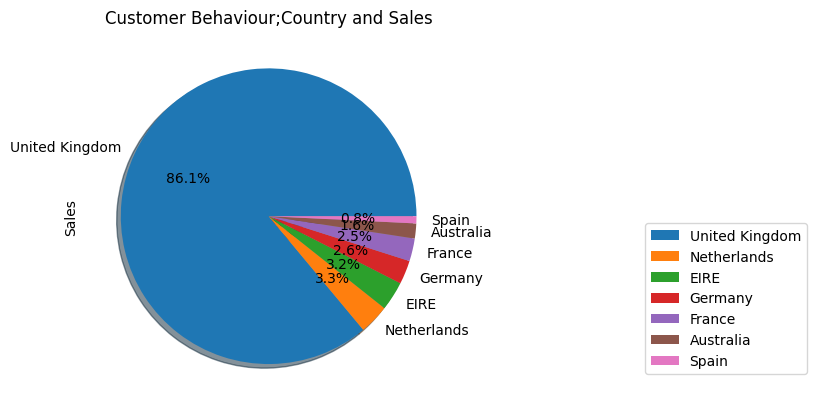

In [88]:
#using a pie chart to represent New_Sales_2
New_Sales_2.head(7).plot(kind='pie',autopct='%1.1f%%',shadow=True)
plt.legend(loc='upper left',bbox_to_anchor=(1.5,0.5))
plt.title('Customer Behaviour;Country and Sales')
plt.show()



In [82]:
#grouping Description and sales
Description_Sales=data[data['InvoiceDate'].dt.year==2010].groupby(['Description'])['Sales'].sum()
Description_Sales

Description
 4 PURPLE FLOCK DINNER CANDLES        35.70
 OVAL WALL MIRROR DIAMANTE            89.55
 SET 2 TEA TOWELS I LOVE LONDON      749.30
10 COLOUR SPACEBOY PEN               474.30
12 COLOURED PARTY BALLOONS            31.20
                                      ...  
ZINC HEART LATTICE CHARGER SMALL      11.80
ZINC HEART LATTICE T-LIGHT HOLDER     30.00
ZINC METAL HEART DECORATION          631.25
ZINC TOP  2 DOOR WOODEN SHELF         93.70
ZINC WILLIE WINKIE  CANDLE STICK     147.90
Name: Sales, Length: 2429, dtype: float64

In [83]:
#sorting the values
Description_Sales_1=Description_Sales.sort_values(ascending=False)
Description_Sales_1

Description
REGENCY CAKESTAND 3 TIER              18554.10
WHITE HANGING HEART T-LIGHT HOLDER    10958.45
VINTAGE UNION JACK MEMOBOARD           6938.49
WOOD BLACK BOARD ANT WHITE FINISH      6698.13
BLACK RECORD COVER FRAME               6248.82
                                        ...   
HEARTS WRAPPING TAPE                      0.65
SILICON STAR BULB  BLUE                   0.42
METAL BASE FOR CANDLES                    0.42
SILICON CUBE 25W, BLUE                    0.42
ASSORTED MONKEY SUCTION CUP HOOK          0.42
Name: Sales, Length: 2429, dtype: float64

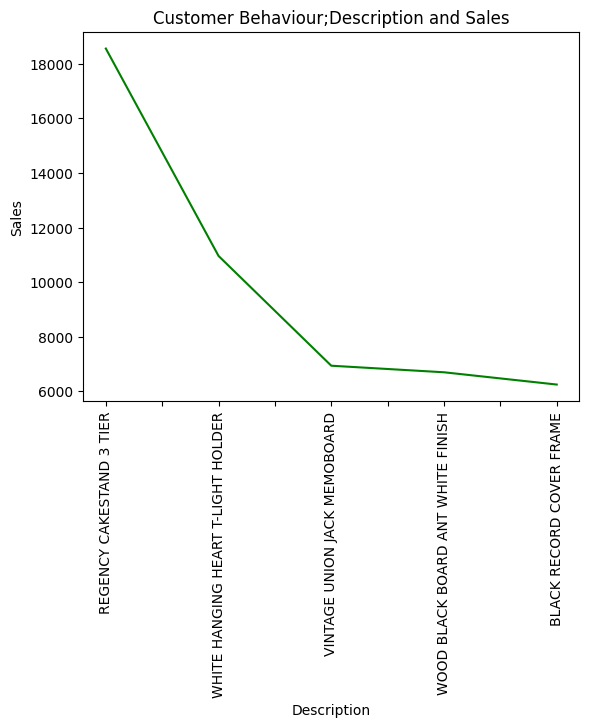

In [84]:
#using a trend to show the data
Description_Sales_1.head(5).head(5).plot(kind='line',color='green')
plt.title('Customer Behaviour;Description and Sales')
rotation=90
plt.xticks(rotation=rotation)
plt.xlabel('Description')
plt.ylabel('Sales')
plt.show()